In [2]:
import warnings
warnings.filterwarnings("ignore")

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

# Add OSAR to path if needed
sys.path.insert(0, r'C:\Users\user\Documents\GitHub\OSAR')
import osar

print(f"OSAR version: {osar.__version__}")

OSAR version: 0.23.7


In [3]:
# Path to data
data_path = r"C:\Users\user\ACC Lab Dropbox\ACC Lab\Nicole Lee\DATA\OSAR\VT999036 x Chrimson2"

# Create OSAR object
o = osar.osar(path_to_data=data_path, driver="VT999036")

print(f"\nLoaded {len(o.flies)} flies")
print(f"\nFly IDs available (first 3): {list(o.tracks.keys())[:3]}")

Creating borders for each fly...
Done.

Processing CSV 40 of 40
Summarising results for all flies...
All done.

Loaded 580 flies

Fly IDs available (first 3): ['VT999036_Chrimson_w1118 x Chrimson2_Eighth_Sibling_2021-08-04_17-50-20_border6.0mm_fly1', 'VT999036_Chrimson_w1118 x Chrimson2_Eighth_Sibling_2021-08-04_17-50-20_border6.0mm_fly2', 'VT999036_Chrimson_w1118 x Chrimson2_Eighth_Sibling_2021-08-04_17-50-20_border6.0mm_fly3']


In [4]:
# Get the first fly ID
fly_id = list(o.tracks.keys())[0]
print(f"Inspecting fly: {fly_id}\n")

# Get the track DataFrame
track = o.tracks[fly_id]

# Show key columns related to position
position_cols = ['Seconds', 'cX', 'cX_smoothed', 'cX_velocity', 'zone_new', 'lightStatus_new']
available_cols = [c for c in position_cols if c in track.columns]
print(f"Position-related columns: {available_cols}\n")
print(track[available_cols].head(10))

Inspecting fly: VT999036_Chrimson_w1118 x Chrimson2_Eighth_Sibling_2021-08-04_17-50-20_border6.0mm_fly1

Position-related columns: ['Seconds', 'cX', 'cX_smoothed', 'cX_velocity', 'zone_new', 'lightStatus_new']

   Seconds       cX  cX_smoothed  cX_velocity  zone_new  lightStatus_new
0    0.000  430.405   435.902242          NaN       3.0              1.0
1    0.041  430.374   437.356282    35.464385       3.0              1.0
2    0.081  430.096   439.074860    42.964452       3.0              1.0
3    0.122  429.966   441.066726    48.582101       3.0              1.0
4    0.163  429.969   443.346233    55.597738       3.0              1.0
5    0.204  431.892   445.941106    63.289593       3.0              1.0
6    0.245  436.901   448.850466    70.959996       3.0              1.0
7    0.285  442.807   452.051578    80.027793       3.0              1.0
8    0.326  447.909   455.529579    84.829285       3.0              1.0
9    0.367  452.892   459.273902    91.324957       3.0    

## Plot Single Fly Track

Visualize how a single fly moved within the chamber over time. The plot shows X-position (horizontal axis) vs Time (vertical axis), with colored backgrounds indicating light/dark regions during illumination epochs.

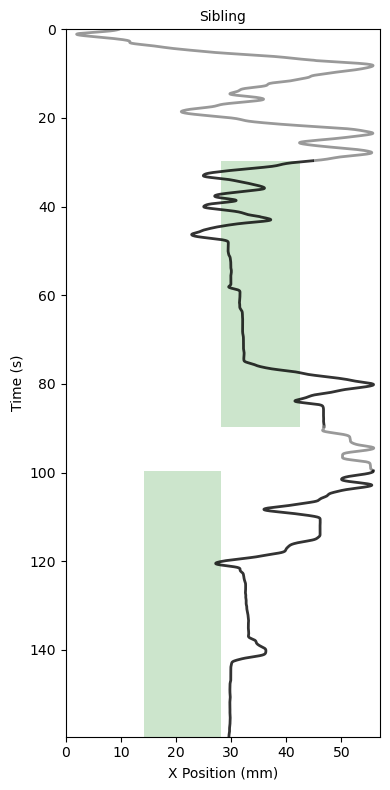

In [ ]:
def plot_fly_track(osar_obj, fly_id, ax=None, track_width=2, light_color='green'):
    """Custom fly track plotter that works with newer matplotlib versions."""
    track = osar_obj.tracks[fly_id].copy()
    PIXEL_MM = osar_obj.PIXEL_LENGTH_MM
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 8))
    
    # Get pattern state column
    ps_col = 'PatternState' if 'PatternState' in track.columns else 'patternState'
    sec_col = 'Seconds' if 'Seconds' in track.columns else 'seconds'
    
    # Get fly metadata for borders
    lane = fly_id.split('_')[-1]
    
    # Plot light regions as background rectangles
    for pattern in ['Pattern 01', 'Pattern 10']:
        if pattern in track[ps_col].values:
            p_slice = track[track[ps_col] == pattern]
            t_start = p_slice[sec_col].min()
            t_end = p_slice[sec_col].max()
            
            try:
                borders = osar_obj.borders.loc[lane, pattern] * PIXEL_MM
                # Light zones
                if pattern == 'Pattern 01':
                    # Light on right side
                    rect = Rectangle((borders['midzone2'], t_start), 
                                     borders['midzone3'] - borders['midzone2'], 
                                     t_end - t_start,
                                     alpha=0.2, facecolor=light_color)
                    ax.add_patch(rect)
                else:
                    # Light on left side  
                    rect = Rectangle((borders['midzone1'], t_start),
                                     borders['midzone2'] - borders['midzone1'],
                                     t_end - t_start,
                                     alpha=0.2, facecolor=light_color)
                    ax.add_patch(rect)
            except:
                pass
    
    # Plot the track - different colors for different patterns
    colors = {'Pattern 01': 'black', 'Pattern 10': 'black', 'EXPT_START': 'gray'}
    
    for pattern in track[ps_col].unique():
        subset = track[track[ps_col] == pattern]
        x = subset['cX_smoothed'] * PIXEL_MM
        y = subset[sec_col]
        color = colors.get(pattern, 'gray')
        ax.plot(x, y, color=color, linewidth=track_width, alpha=0.8)
    
    ax.set_xlim(0, 57)
    ax.set_ylim(track[sec_col].max(), 0)  # Invert y-axis (time goes down)
    ax.set_xlabel('X Position (mm)')
    ax.set_ylabel('Time (s)')
    ax.set_title(fly_id.split('_')[4], fontsize=10)  # Show status (Offspring/Sibling)
    
    return ax

# Plot a single fly
fly_id = list(o.tracks.keys())[0]
fig, ax = plt.subplots(figsize=(4, 8))
plot_fly_track(o, fly_id, ax=ax)
plt.tight_layout()
plt.show()

## Plot Multiple Fly Tracks

Compare movement traces across several flies (Offspring at Full light intensity).

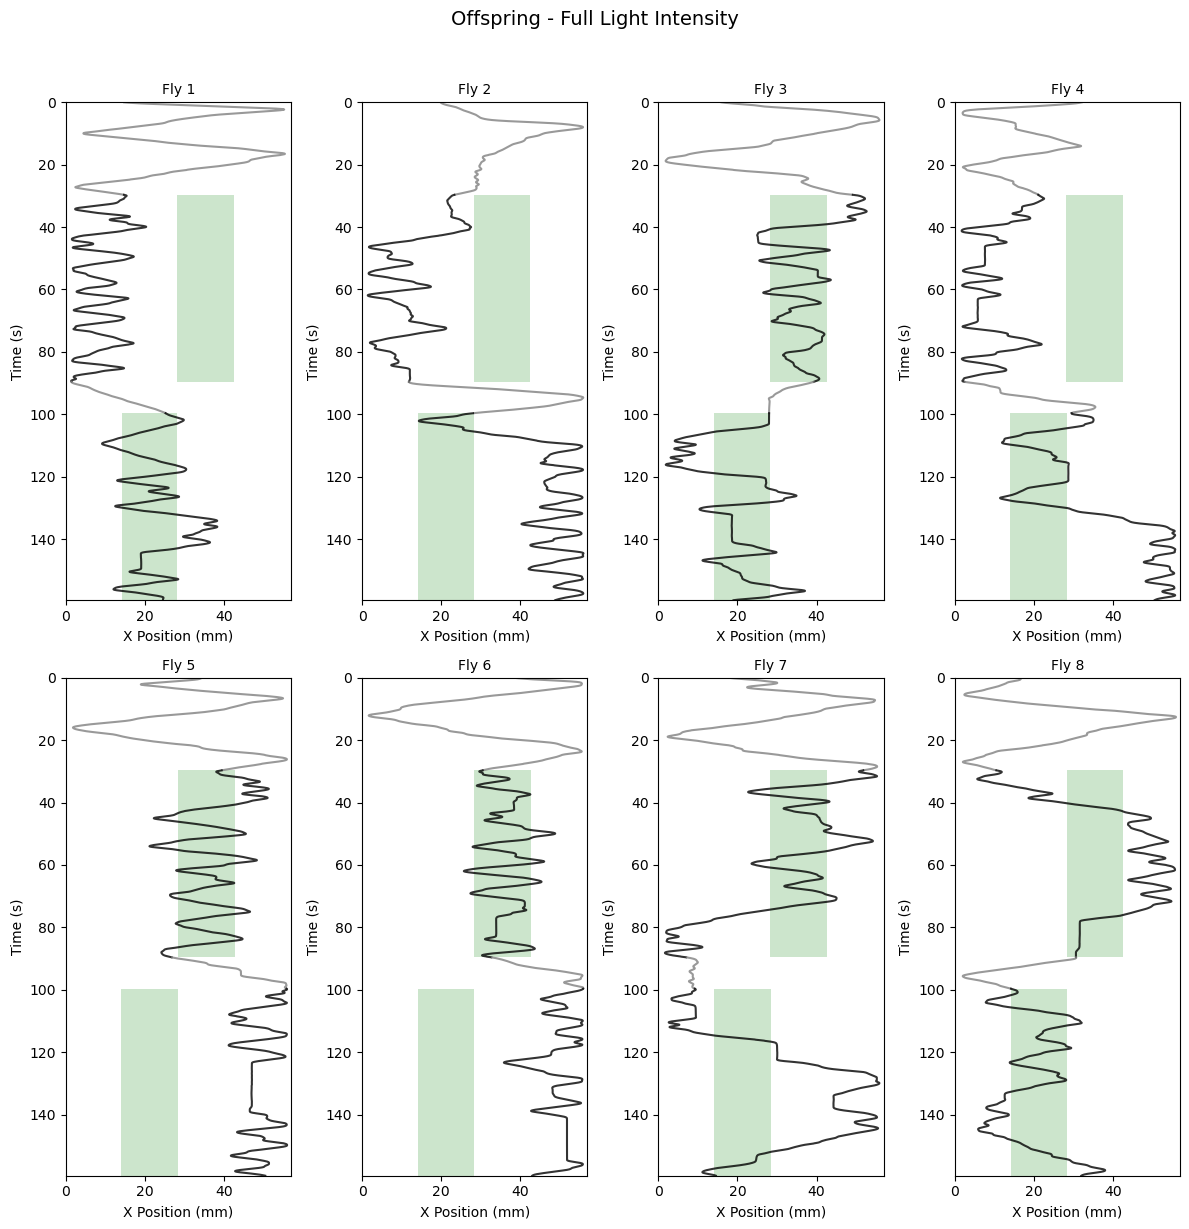

In [5]:
# Get flies matching criteria
offspring_full = o.flies[(o.flies['status'] == 'Offspring') & 
                          (o.flies['light_intensity'] == 'Full')].index.tolist()

# Plot first 8 flies in a grid
n_flies = min(8, len(offspring_full))
ncols = 4
nrows = int(np.ceil(n_flies / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6*nrows))
axes = axes.flatten()

for i, fly_id in enumerate(offspring_full[:n_flies]):
    plot_fly_track(o, fly_id, ax=axes[i], track_width=1.5)
    axes[i].set_title(f'Fly {i+1}', fontsize=10)

# Hide empty axes
for j in range(n_flies, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Offspring - Full Light Intensity', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

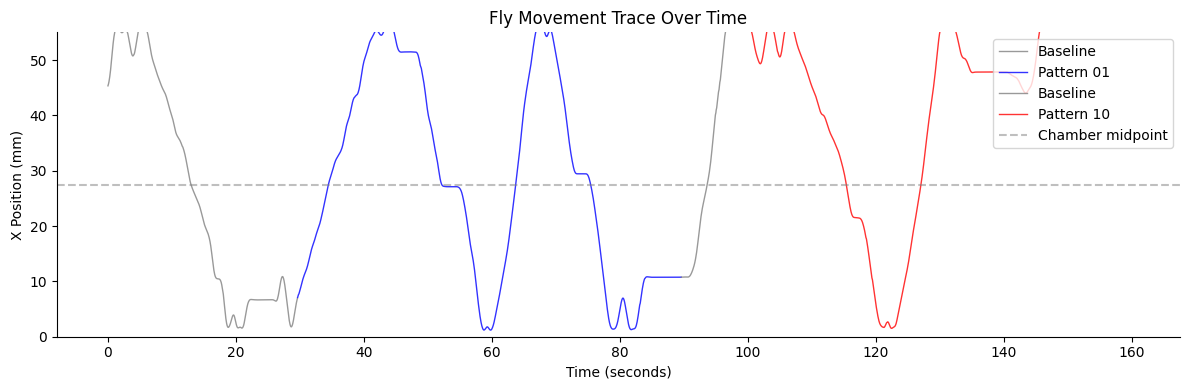

In [28]:
# Custom plot showing X position over time
fly_id = list(o.tracks.keys())[0]
track = o.tracks[fly_id]

fig, ax = plt.subplots(figsize=(12, 4))

# Convert pixel position to mm
x_mm = track['cX_smoothed'] * o.PIXEL_LENGTH_MM

# Color by pattern state
ps_col = 'PatternState' if 'PatternState' in track.columns else 'patternState'
colors = {'Pattern 01': 'blue', 'Pattern 10': 'red'}

for pattern in track[ps_col].unique():
    subset = track[track[ps_col] == pattern]
    x_pos = subset['cX_smoothed'] * o.PIXEL_LENGTH_MM
    color = colors.get(pattern, 'gray')
    label = pattern if pattern in colors else 'Baseline'
    ax.plot(subset['Seconds'], x_pos, color=color, linewidth=1, alpha=0.8, label=label)

ax.set_xlabel('Time (seconds)')
ax.set_ylabel('X Position (mm)')
ax.set_title(f'Fly Movement Trace Over Time')
ax.axhline(y=27.5, color='gray', linestyle='--', alpha=0.5, label='Chamber midpoint')
ax.legend(loc='upper right')
ax.set_ylim(0, 55)
sns.despine()
plt.tight_layout()
plt.show()

## Fly Path Map - Pattern 01 Only

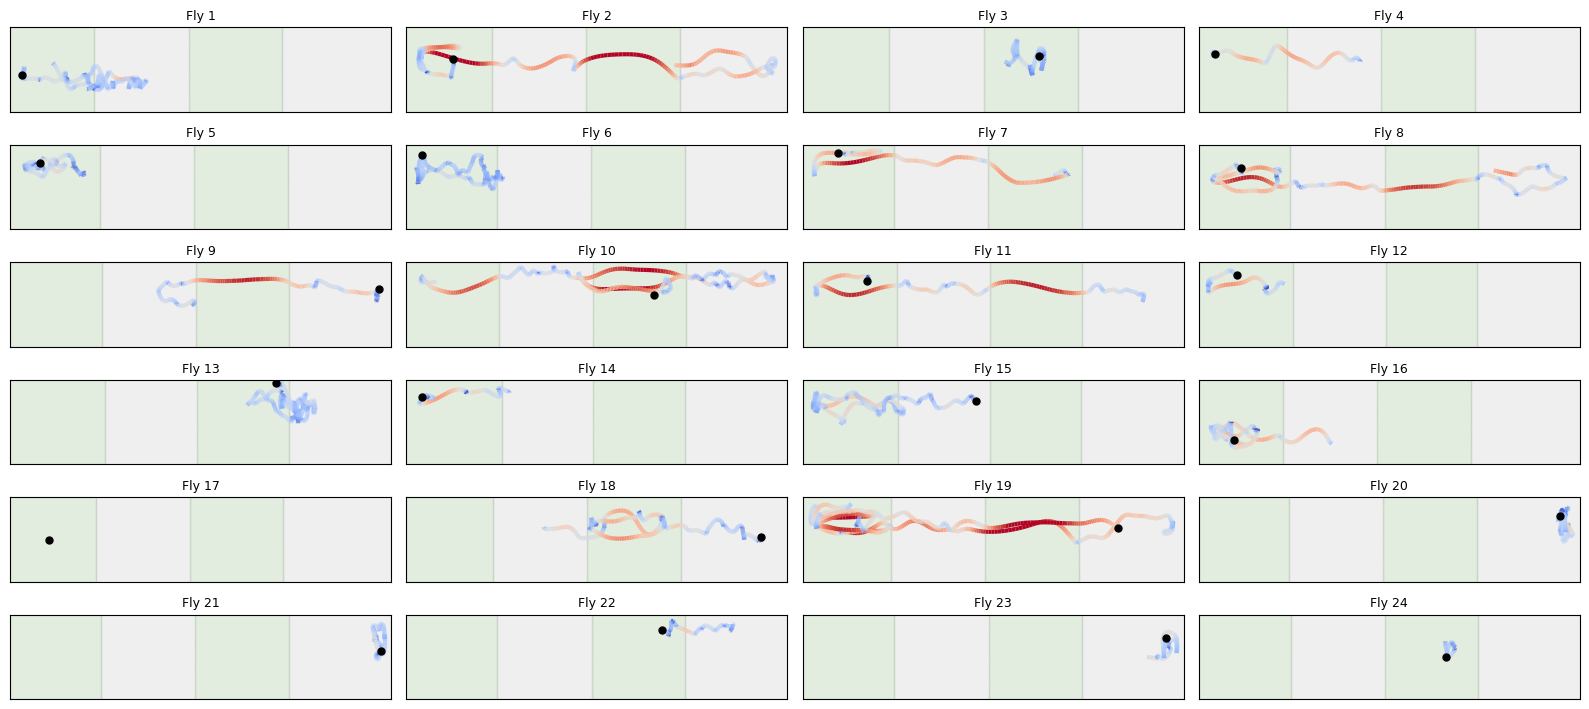

In [11]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, PowerNorm

offspring_full = o.flies[(o.flies['status'] == 'Offspring') & (o.flies['light_intensity'] == 'Full')].index.tolist()
n_flies = min(24, len(offspring_full))

ps_col = 'PatternState' if 'PatternState' in o.tracks[offspring_full[0]].columns else 'patternState'
PX = o.PIXEL_LENGTH_MM

all_p01 = pd.concat([o.tracks[fid][o.tracks[fid][ps_col] == 'Pattern 01'][['zone_new','lightStatus_new']] for fid in offspring_full])
zone_lit = {}
for z in [1, 2, 3]:
    sub = all_p01[all_p01['zone_new'] == z]['lightStatus_new'].dropna()
    zone_lit[z] = sub.mode().iloc[0] == 1 if len(sub) > 0 else False

# ---- CONFIG ----
cmap = plt.cm.coolwarm  # red = slow (dwelling), blue = fast (passing)
SMOOTH_WINDOW = 15  # rolling average window for speed smoothing (frames)
GAMMA = 0.5  # <1 pushes colors toward extremes for more contrast
VMIN = 0    # colorbar min (mm/s)
VMAX = 10  # colorbar max (mm/s)

subplot_height = 1.2
ncols = 4
nrows = int(np.ceil(n_flies / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, subplot_height * nrows), sharey=True)
axes = axes.flatten()

color_norm = PowerNorm(gamma=GAMMA, vmin=VMIN, vmax=VMAX)

for i, fly_id in enumerate(offspring_full[:n_flies]):
    ax = axes[i]
    track = o.tracks[fly_id]
    p01 = track[track[ps_col] == 'Pattern 01'].copy()

    lane = fly_id.split('_')[-1]
    b = o.borders.loc[lane, 'Pattern 01'] * PX
    chamber_width = 57

    zones = [
        (0, b['midzone1'], zone_lit[1]),
        (b['midzone1'], b['midzone2'], zone_lit[2]),
        (b['midzone2'], b['midzone3'], zone_lit[3]),
        (b['midzone3'], chamber_width, False)
    ]
    for x0, x1, lit in zones:
        ax.fill_between([x0, x1], 0, 4, color="#3F812E" if lit else '#333333', alpha=0.15 if lit else 0.08)
    for border in [b['midzone1'], b['midzone2'], b['midzone3']]:
        ax.axvline(border, color="#FFFFFF", ls='--', lw=0.4, alpha=0.4)

    x = (p01['cX_smoothed'] * PX).values
    y = (p01['cY_smoothed'] * PX).values
    t = p01['Seconds'].values

    # Compute 2D speed from smoothed position differences (mm/s)
    dt = np.diff(t)
    dx = np.diff(x)
    dy = np.diff(y)
    dt_safe = np.where(dt > 0, dt, np.nan)
    speed = np.sqrt((dx / dt_safe)**2 + (dy / dt_safe)**2)

    # Smooth speed with a rolling average for cleaner color transitions
    kernel = np.ones(SMOOTH_WINDOW) / SMOOTH_WINDOW
    speed_smooth = np.convolve(speed, kernel, mode='same')
    speed_smooth = np.nan_to_num(speed_smooth, nan=0.0)

    points = np.column_stack([x, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=color_norm, linewidths=3)
    lc.set_array(speed_smooth)
    ax.add_collection(lc)

    ax.plot(x[-1], y[-1], 'o', color='black', markersize=5, zorder=5)

    ax.set_xlim(0, chamber_width)
    ax.set_ylim(0, 4)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(f'Fly {i+1}', fontsize=9)
    ax.tick_params(axis='x', labelsize=7)

for j in range(n_flies, len(axes)):
    axes[j].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=color_norm)
sm.set_array([])
# cbar = fig.colorbar(sm, ax=axes[:n_flies], pad=0.02, aspect=30, shrink=0.6)
# cbar.set_label('Speed (mm/s)', fontsize=9)
# cbar.set_ticks([VMIN, VMAX])
# cbar.set_ticklabels([f'{VMIN} mm/s (dwelling)', f'{VMAX} mm/s (passing)'])

plt.tight_layout()
plt.show()